# Finding Similar NBA Players Using Cosine Similarity

## Import libraries
This cell imports the Python libraries needed for data loading, normalization, and cosine similarity calculations.

In [32]:
import pandas as pd
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

## Load the dataset
This cell loads the 2024–25 NBA player per-game statistics dataset from a CSV file.

In [33]:
df = pd.read_csv("2024_25_NBA_Player Stats_Per_Game.csv")
df.head()

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
0,1,Shai Gilgeous-Alexander,26,OKC,PG,76,76,34.2,11.3,21.8,...,0.9,4.1,5.0,6.4,1.7,1.0,2.4,2.2,32.7,"MVP-1,DPOY-10,CPOY-8,AS,NBA1"
1,2,Giannis Antetokounmpo,30,MIL,PF,67,67,34.2,11.8,19.7,...,2.2,9.7,11.9,6.5,0.9,1.2,3.1,2.3,30.4,"MVP-3,DPOY-8,AS,NBA1"
2,3,Nikola Jokić,29,DEN,C,70,70,36.7,11.2,19.5,...,2.9,9.9,12.7,10.2,1.8,0.6,3.3,2.3,29.6,"MVP-2,CPOY-2,AS,NBA1"
3,4,Luka Dončić,25,2TM,PG,50,50,35.4,9.2,20.5,...,0.8,7.4,8.2,7.7,1.8,0.4,3.6,2.5,28.2,NaN
4,4,Luka Dončić,25,DAL,PG,22,22,35.7,9.8,21.2,...,0.7,7.6,8.3,7.8,2.0,0.4,3.4,2.6,28.1,NaN


## Clean repeated header rows and missing player names
Basketball Reference tables sometimes include repeated header rows inside the dataset. This cell removes those rows and drops rows with missing player names.

In [34]:
df = df[df["Player"] != "Player"]
df = df.dropna(subset=["Player"])
df.head()

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
0,1,Shai Gilgeous-Alexander,26,OKC,PG,76,76,34.2,11.3,21.8,...,0.9,4.1,5.0,6.4,1.7,1.0,2.4,2.2,32.7,"MVP-1,DPOY-10,CPOY-8,AS,NBA1"
1,2,Giannis Antetokounmpo,30,MIL,PF,67,67,34.2,11.8,19.7,...,2.2,9.7,11.9,6.5,0.9,1.2,3.1,2.3,30.4,"MVP-3,DPOY-8,AS,NBA1"
2,3,Nikola Jokić,29,DEN,C,70,70,36.7,11.2,19.5,...,2.9,9.9,12.7,10.2,1.8,0.6,3.3,2.3,29.6,"MVP-2,CPOY-2,AS,NBA1"
3,4,Luka Dončić,25,2TM,PG,50,50,35.4,9.2,20.5,...,0.8,7.4,8.2,7.7,1.8,0.4,3.6,2.5,28.2,NaN
4,4,Luka Dončić,25,DAL,PG,22,22,35.7,9.8,21.2,...,0.7,7.6,8.3,7.8,2.0,0.4,3.4,2.6,28.1,NaN


## Keep one row per player
Some players appear multiple times because they played for more than one team during the season. In those cases, Basketball Reference includes separate team rows plus a total row labeled "2TM". This cell keeps the total row when available and removes duplicate team-specific rows.

In [35]:
df["is_total"] = (df["Team"] == "2TM").astype(int)

df_clean = (
    df.sort_values(["Player", "is_total"], ascending=[True, False])
      .drop_duplicates(subset="Player", keep="first")
      .drop(columns="is_total")
      .reset_index(drop=True)
)

df_clean["Player"].value_counts().head(10)

Player
A.J. Green         1
Kyle Kuzma         1
Marcus Sasser      1
Marcus Garrett     1
Marcus Bagley      1
Malik Monk         1
Malik Beasley      1
Malcolm Brogdon    1
Malaki Branham     1
Luke Kornet        1
Name: count, dtype: int64

## Select the features for similarity analysis
This cell defines the player statistics that will be used as features in the similarity analysis.

In [36]:
features = ["MP", "FG%", "3P%", "FT%", "TRB", "AST", "STL", "BLK", "TOV", "PTS"]

player_stats = df_clean[["Player"] + features].copy()
player_stats.head()

,Player,MP,FG%,3P%,FT%,TRB,AST,STL,BLK,TOV,PTS
0,A.J. Green,22.7,0.429,0.427,0.815,2.4,1.5,0.5,0.1,0.5,7.4
1,A.J. Lawson,18.7,0.421,0.327,0.683,3.3,1.2,0.5,0.2,0.6,9.1
2,AJ Johnson,22.0,0.385,0.267,0.865,2.0,2.6,0.4,0.1,1.2,7.6
3,Aaron Gordon,28.4,0.531,0.436,0.810,4.8,3.2,0.5,0.3,1.4,14.7
4,Aaron Holiday,12.8,0.437,0.398,0.829,1.3,1.3,0.3,0.2,0.6,5.5


## Convert selected features to numeric values
This cell makes sure that all feature columns are numeric so they can be used in mathematical similarity calculations.

In [37]:
for col in features:
    player_stats[col] = pd.to_numeric(player_stats[col], errors="coerce")

player_stats = player_stats.dropna()
player_stats.head()

,Player,MP,FG%,3P%,FT%,TRB,AST,STL,BLK,TOV,PTS
0,A.J. Green,22.7,0.429,0.427,0.815,2.4,1.5,0.5,0.1,0.5,7.4
1,A.J. Lawson,18.7,0.421,0.327,0.683,3.3,1.2,0.5,0.2,0.6,9.1
2,AJ Johnson,22.0,0.385,0.267,0.865,2.0,2.6,0.4,0.1,1.2,7.6
3,Aaron Gordon,28.4,0.531,0.436,0.810,4.8,3.2,0.5,0.3,1.4,14.7
4,Aaron Holiday,12.8,0.437,0.398,0.829,1.3,1.3,0.3,0.2,0.6,5.5


## Normalize player feature vectors
This cell applies L2 normalization so that players can be compared based on the shape of their statistical profiles rather than just raw magnitude.

In [38]:
X = player_stats[features]
X_norm = normalize(X, norm="l2")

## Compute cosine similarity
This cell computes cosine similarity between every pair of players using the normalized feature matrix.

In [39]:
similarity_matrix = cosine_similarity(X_norm)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=player_stats["Player"],
    columns=player_stats["Player"]
)

similarity_df.head()

Player,A.J. Green,A.J. Lawson,AJ Johnson,Aaron Gordon,Aaron Holiday,Aaron Nesmith,Aaron Wiggins,Adem Bona,Ajay Mitchell,Al Horford,...,Vít Krejčí,Walker Kessler,Wendell Carter Jr.,Yves Missi,Zaccharie Risacher,Zach Collins,Zach Edey,Zach LaVine,Ziaire Williams,Zion Williamson
Player,,,,,,,,,,,,,,,,,,,,,
A.J. Green,1.000000,0.989057,0.998091,0.985004,0.994752,0.989983,0.984936,0.984478,0.997065,0.993632,...,0.997269,0.962127,0.987215,0.982268,0.986737,0.981816,0.965729,0.962823,0.994369,0.917252
A.J. Lawson,0.989057,1.000000,0.988676,0.998625,0.995637,0.999777,0.999428,0.988387,0.994316,0.989087,...,0.991433,0.972208,0.988590,0.983989,0.999139,0.991210,0.980864,0.988315,0.997592,0.963390
AJ Johnson,0.998091,0.988676,1.000000,0.987649,0.996608,0.989050,0.985909,0.981025,0.998523,0.990779,...,0.998804,0.957438,0.984466,0.977940,0.986883,0.981695,0.961927,0.968701,0.992580,0.926156
Aaron Gordon,0.985004,0.998625,0.987649,1.000000,0.995117,0.997808,0.999362,0.983303,0.993227,0.984639,...,0.990445,0.967115,0.984490,0.978625,0.998178,0.989511,0.976638,0.993033,0.994292,0.971965
Aaron Holiday,0.994752,0.995637,0.996608,0.995117,1.000000,0.995957,0.994623,0.982739,0.999064,0.988054,...,0.996705,0.958925,0.983486,0.976823,0.995095,0.985178,0.967067,0.982956,0.995002,0.948574


## Define a function to find the most similar players
This helper function returns the top 10 players most similar to a selected query player.

In [40]:
def top_similar(player_name, similarity_df, n=10):
    return similarity_df[player_name].sort_values(ascending=False)[1:n+1]

## Choose the query players
For this analysis, the three query players are LeBron James, Stephen Curry, and Nikola Jokić.

In [41]:
query_players = ["LeBron James", "Stephen Curry", "Nikola Jokić"]

[player for player in similarity_df.index if "Nikola" in player]

['Nikola Jokić', 'Nikola Jović', 'Nikola Vučević']

## Display the top 10 most similar players for each query player
This cell prints the top 10 most similar players for each of the three selected query players.

In [42]:
for player in query_players:
    print(f"\nTop 10 players most similar to {player}:")
    print(top_similar(player, similarity_df))


Top 10 players most similar to LeBron James:
Player
Cade Cunningham    0.998475
James Harden       0.998147
RJ Barrett         0.998075
Jayson Tatum       0.997799
Luka Dončić        0.997791
Brandon Ingram     0.997231
Damian Lillard     0.996658
LaMelo Ball        0.996602
Jalen Williams     0.996505
Ja Morant          0.996417
Name: LeBron James, dtype: float64

Top 10 players most similar to Stephen Curry:
Player
Donovan Mitchell    0.999567
LaMelo Ball         0.999162
Ja Morant           0.998851
Damian Lillard      0.998822
Anthony Edwards     0.998675
Jalen Brunson       0.998667
Devin Booker        0.998579
Jordan Poole        0.998512
Franz Wagner        0.998508
Cam Thomas          0.998302
Name: Stephen Curry, dtype: float64

Top 10 players most similar to Nikola Jokić:
Player
Giannis Antetokounmpo    0.996297
Luka Dončić              0.995745
Zion Williamson          0.994377
LeBron James             0.994241
Joel Embiid              0.994000
Jayson Tatum             0.99

## Convert the results into tables
This cell creates cleaner tables for the top 10 most similar players to each query player.

In [43]:
lebron_top10 = top_similar("LeBron James", similarity_df).reset_index()
lebron_top10.columns = ["Player", "Cosine Similarity"]

curry_top10 = top_similar("Stephen Curry", similarity_df).reset_index()
curry_top10.columns = ["Player", "Cosine Similarity"]

jokic_top10 = top_similar("Nikola Jokić", similarity_df).reset_index()
jokic_top10.columns = ["Player", "Cosine Similarity"]

## Show final similarity tables
These tables summarize the top 10 most similar players for LeBron James, Stephen Curry, and Nikola Jokić.

In [44]:
lebron_top10["Cosine Similarity"] = lebron_top10["Cosine Similarity"].round(4)
curry_top10["Cosine Similarity"] = curry_top10["Cosine Similarity"].round(4)
jokic_top10["Cosine Similarity"] = jokic_top10["Cosine Similarity"].round(4)

print("LeBron James")
display(lebron_top10)

print("Stephen Curry")
display(curry_top10)

print("Nikola Jokić")
display(jokic_top10)

LeBron James


,Player,Cosine Similarity
0,Cade Cunningham,0.9985
1,James Harden,0.9981
2,RJ Barrett,0.9981
3,Jayson Tatum,0.9978
4,Luka Dončić,0.9978
5,Brandon Ingram,0.9972
6,Damian Lillard,0.9967
7,LaMelo Ball,0.9966
8,Jalen Williams,0.9965
9,Ja Morant,0.9964


Stephen Curry


,Player,Cosine Similarity
0,Donovan Mitchell,0.9996
1,LaMelo Ball,0.9992
2,Ja Morant,0.9989
3,Damian Lillard,0.9988
4,Anthony Edwards,0.9987
5,Jalen Brunson,0.9987
6,Devin Booker,0.9986
7,Jordan Poole,0.9985
8,Franz Wagner,0.9985
9,Cam Thomas,0.9983


Nikola Jokić


,Player,Cosine Similarity
0,Giannis Antetokounmpo,0.9963
1,Luka Dončić,0.9957
2,Zion Williamson,0.9944
3,LeBron James,0.9942
4,Joel Embiid,0.9940
5,Jayson Tatum,0.9936
6,Cade Cunningham,0.9914
7,Paolo Banchero,0.9907
8,Anthony Davis,0.9904
9,LaMelo Ball,0.9895


In [45]:
display(
    lebron_top10.style.hide(axis="index")
    .set_caption("Top 10 Players Most Similar to LeBron James")
    .format({"Cosine Similarity": "{:.4f}"})
)

display(
    curry_top10.style.hide(axis="index")
    .set_caption("Top 10 Players Most Similar to Stephen Curry")
    .format({"Cosine Similarity": "{:.4f}"})
)

display(
    jokic_top10.style.hide(axis="index")
    .set_caption("Top 10 Players Most Similar to Nikola Jokić")
    .format({"Cosine Similarity": "{:.4f}"})
)

Player,Cosine Similarity
Cade Cunningham,0.9985
James Harden,0.9981
RJ Barrett,0.9981
Jayson Tatum,0.9978
Luka Dončić,0.9978
Brandon Ingram,0.9972
Damian Lillard,0.9967
LaMelo Ball,0.9966
Jalen Williams,0.9965
Ja Morant,0.9964


Player,Cosine Similarity
Donovan Mitchell,0.9996
LaMelo Ball,0.9992
Ja Morant,0.9989
Damian Lillard,0.9988
Anthony Edwards,0.9987
Jalen Brunson,0.9987
Devin Booker,0.9986
Jordan Poole,0.9985
Franz Wagner,0.9985
Cam Thomas,0.9983


Player,Cosine Similarity
Giannis Antetokounmpo,0.9963
Luka Dončić,0.9957
Zion Williamson,0.9944
LeBron James,0.9942
Joel Embiid,0.9940
Jayson Tatum,0.9936
Cade Cunningham,0.9914
Paolo Banchero,0.9907
Anthony Davis,0.9904
LaMelo Ball,0.9895


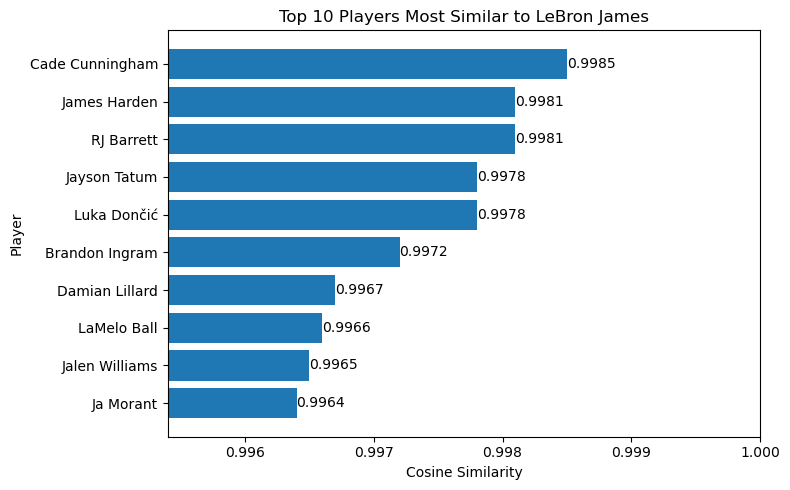

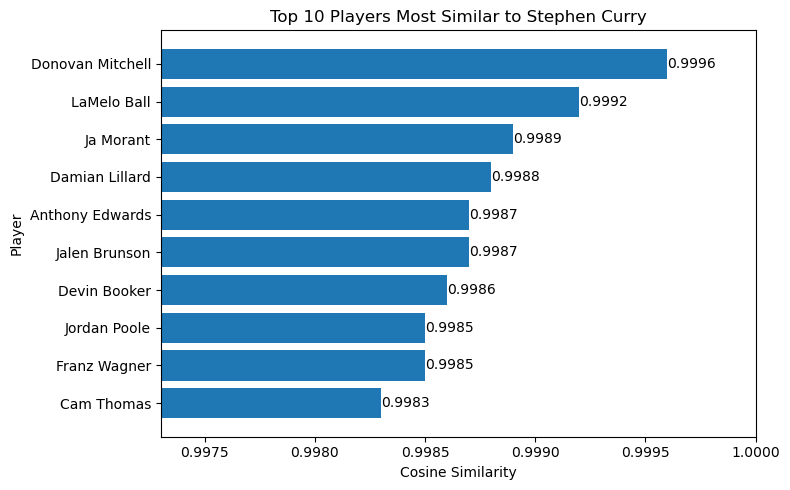

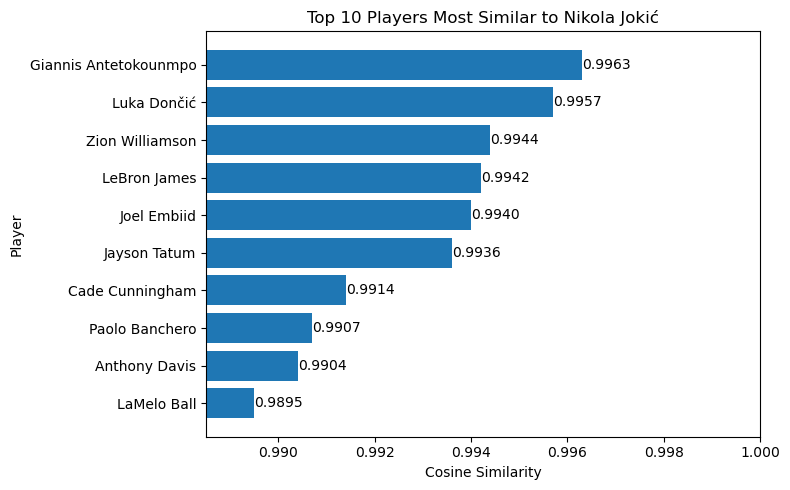

In [46]:
def similarity_chart(df, title):
    plt.figure(figsize=(8, 5))
    bars = plt.barh(df["Player"], df["Cosine Similarity"])

    plt.xlabel("Cosine Similarity")
    plt.ylabel("Player")
    plt.title(title)

    plt.xlim(df["Cosine Similarity"].min() - 0.001, 1.0)

    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2,
                 f'{width:.4f}', va='center')

    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


similarity_chart(lebron_top10, "Top 10 Players Most Similar to LeBron James")
similarity_chart(curry_top10, "Top 10 Players Most Similar to Stephen Curry")
similarity_chart(jokic_top10, "Top 10 Players Most Similar to Nikola Jokić")

## Summary of Results

Using cosine similarity on normalized player statistics, we identified players with similar statistical profiles to LeBron James, Stephen Curry, and Nikola Jokić.

LeBron James is most similar to players who are high-usage scorers and playmakers such as Cade Cunningham, James Harden, and Luka Dončić.

Stephen Curry is most similar to scoring guards and perimeter shooters such as Donovan Mitchell, Damian Lillard, and Devin Booker.

Nikola Jokić is most similar to versatile big men and point-forwards such as Giannis Antetokounmpo, Luka Dončić, Joel Embiid, and LeBron James.

These results show that cosine similarity can be used to group players based on statistical playing style rather than position alone.